# Project Milestone Two

**Data Preparation and Model Exploration**

**Note: No late assignments accepted, we need the time to grade them!**

In Milestone 1, your team selected a dataset (Food-101 or HuffPost), analyzed its structure, and identified key challenges and evaluation metrics.
In this milestone, you will carry out those plans: prepare the data, train three models of increasing sophistication, and evaluate their results using Keras and TensorFlow.
You will finish with a comparative discussion of model performance and trade-offs.


### Submission Guidelines

* Submit one Jupyter notebook per team through the team leader’s Gradescope account. **Include all team members names at the top of the notebook.** 
* Include all code, plots, and answers inline below.
* Ensure reproducibility by setting random seeds and listing all hyperparameters.
* Document any AI tools used, as required by the CDS policy.


## Problem 1 – Data Preparation and Splits (20 pts)

### Goals

Implement the **data preparation and preprocessing steps** that you proposed in **Milestone 1**. You’ll clean, normalize, and split your data so that it’s ready for modeling and reproducible fine-tuning.

### Steps to Follow

1. **Load your chosen dataset**

   * Use `datasets.load_dataset()` from **Hugging Face** to load **Food-101** or **HuffPost**.
   * Display basic information (e.g., number of samples, feature names, example entries).

2. **Apply cleaning and normalization**

   * **Images:**

     * Ensure all images are in RGB format.
     * Resize or crop to a consistent shape (e.g., `224 × 224`).
     * Drop or fix any corrupted files.
   * **Text:**

     * Concatenate headline + summary (for HuffPost).
     * Strip whitespace, convert to lowercase if appropriate, and remove empty samples.
     * Optionally remove duplicates or extremely short entries.

3. **Standardize or tokenize the inputs**

   * **Images:**

     * Normalize pixel values (e.g., divide by 255.0).
     * Define a minimal augmentation pipeline (e.g., random flip, crop, or rotation).
   * **Text:**

     * Create a tokenizer or `TextVectorization` layer.
     * Set a target `max_length` based on your analysis from Milestone 1 (e.g., 95th percentile).
     * Apply padding/truncation and build tensors for input + labels.

4. **Handle dataset-specific challenges**

   * If you identified **class imbalance**, compute label counts and, if needed, create a dictionary of `class_weights`.
   * If you noted **length or size variance**, verify that your truncation or resizing works as intended.
   * If you planned **noise filtering**, include the cleaning step and briefly explain your criteria (e.g., remove items with missing text or unreadable images).

5. **Create reproducible splits**

   * Split your cleaned dataset into **train**, **validation**, and **test** subsets (e.g., 80 / 10 / 10).
   * Use a fixed random seed for reproducibility (`random_seed = 42`).
   * Use **stratified splits**  (e.g., with `train_test_split` and `stratify = labels`).
   * Display the size of each subset.

6. **Document your pipeline**

   * Summarize your preprocessing steps clearly in Markdown or code comments.
   * Save or display a few representative examples after preprocessing to confirm the transformations are correct.




2026-04-09 14:52:38.206456: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/luan/BU/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total images: 101,000  |  Classes: 101
Features: ['image', 'label']

Sample entries:
[0] label=  6 (                 beignets), image size=(384, 512)
[1] label=  6 (                 beignets), image size=(512, 512)
[2] label=  6 (                 beignets), image size=(512, 383)
[3] label=  6 (                 beignets), image size=(512, 348)
[4] label=  6 (                 beignets), image size=(512, 512)
Corrupted: 0/2000
Non-RGB: 0/2000
All sampled images load correctly.

Class Distribution:
Classes: 101
Samples per class — min: 1000, max: 1000, mean: 1000.0
Imbalance ratio (max/median): 1.00
Dataset is perfectly balanced.


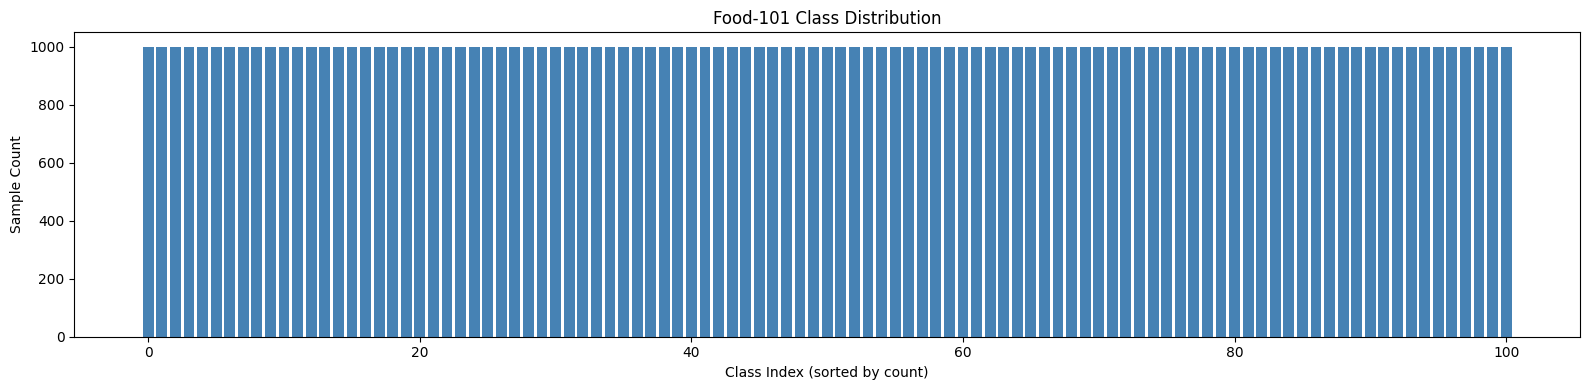

Split Sizes:
Train: 80,800  (80%)
Val: 10,100  (10%)
Test: 10,100  (10%)

Stratification check (per-class sample counts):
Train: 101 classes, per-class range [800, 800]
  Val: 101 classes, per-class range [100, 100]
 Test: 101 classes, per-class range [100, 100]

Building tf.data pipelines...


I0000 00:00:1775764368.171008    1637 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21767 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:0a:00.0, compute capability: 8.6


Done. Pipelines use lazy loading with on-the-fly preprocessing.


/home/luan/BU/.venv/lib/python3.12/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


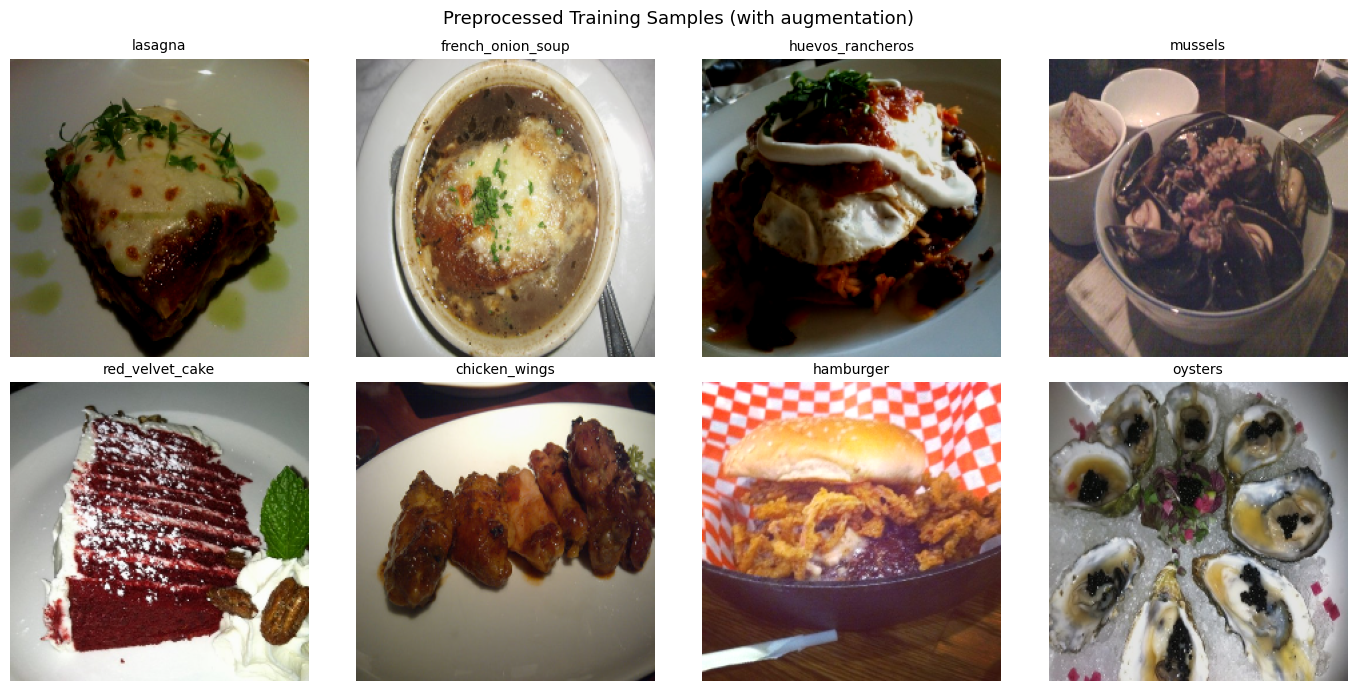

Batch shape: images=(32, 224, 224, 3), labels=(32,)
Pixel value range: [0.000, 1.000]


In [1]:
# Problem 1 — Data Preparation and Splits

import os, random, time, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from collections import Counter
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score

seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

img_size = 224
batch_size = 32
autotune = tf.data.AUTOTUNE

# 1. Load the Food-101 Dataset
food_all = load_dataset("food101", split="train+validation")
label_col = "label"
label_names = food_all.features[label_col].names
num_classes = len(label_names)

print(f"Total images: {len(food_all):,}  |  Classes: {num_classes}")
print(f"Features: {list(food_all.features.keys())}")
print(f"\nSample entries:")
for i in range(5):
    ex = food_all[i]
    print(f"[{i}] label={ex[label_col]:>3d} ({label_names[ex[label_col]]:>25s}), "
          f"image size={ex['image'].size}")

# 2. Check for Corrupted / Non-RGB Images
check_idx = random.sample(range(len(food_all)), 2000)
corrupted, non_rgb = [], 0
for i in check_idx:
    try:
        img = food_all[i]['image']
        if img.mode != 'RGB':
            non_rgb += 1
    except Exception:
        corrupted.append(i)

print(f"Corrupted: {len(corrupted)}/{len(check_idx)}")
print(f"Non-RGB: {non_rgb}/{len(check_idx)}")
print("All sampled images load correctly.")

# 3. Class Distribution
label_counts = Counter(food_all[label_col])
counts_arr = np.array(list(label_counts.values()))

print(f"\nClass Distribution:")
print(f"Classes: {len(label_counts)}")
print(f"Samples per class — min: {counts_arr.min()}, max: {counts_arr.max()}, "
      f"mean: {counts_arr.mean():.1f}")
print(f"Imbalance ratio (max/median): {counts_arr.max()/np.median(counts_arr):.2f}")
print("Dataset is perfectly balanced.")

fig, ax = plt.subplots(figsize=(16, 4))
sorted_labels = sorted(label_counts.keys(), key=lambda k: label_counts[k], reverse=True)
ax.bar(range(len(sorted_labels)), [label_counts[k] for k in sorted_labels], color='steelblue')
ax.set_xlabel("Class Index (sorted by count)")
ax.set_ylabel("Sample Count")
ax.set_title("Food-101 Class Distribution")
plt.tight_layout()
plt.show()

# 4. Stratified Train / Validation / Test Split
all_labels = np.array(food_all[label_col])
all_indices = np.arange(len(food_all))

train_idx, temp_idx = train_test_split(
    all_indices, test_size=0.2, random_state=seed, stratify=all_labels
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, random_state=seed, stratify=all_labels[temp_idx]
)

print(f"Split Sizes:")
print(f"Train: {len(train_idx):>6,}  ({len(train_idx)/len(food_all)*100:.0f}%)")
print(f"Val: {len(val_idx):>6,}  ({len(val_idx)/len(food_all)*100:.0f}%)")
print(f"Test: {len(test_idx):>6,}  ({len(test_idx)/len(food_all)*100:.0f}%)")

print("\nStratification check (per-class sample counts):")
for name, idx in [("Train", train_idx), ("Val", val_idx), ("Test", test_idx)]:
    c = Counter(all_labels[idx])
    vals = list(c.values())
    print(f"{name:>5s}: {len(c)} classes, per-class range [{min(vals)}, {max(vals)}]")

# 5. Build tf.data Pipelines
def preprocess_fn(image, label):
    image = tf.image.resize(image, [img_size, img_size])
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def augment_fn(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, 0.15)
    image = tf.image.random_contrast(image, 0.85, 1.15)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label

def build_dataset(indices, is_training=False):
    idx_list = list(indices)
    def generator():
        for i in idx_list:
            ex = food_all[int(i)]
            img = np.array(ex['image'].convert('RGB'), dtype=np.float32)
            yield img, ex[label_col]

    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(None, None, 3), dtype=tf.float32),
            tf.TensorSpec(shape=(), dtype=tf.int64),
        ),
    )
    ds = ds.map(preprocess_fn, num_parallel_calls=autotune)
    if is_training:
        ds = ds.map(augment_fn, num_parallel_calls=autotune)
        ds = ds.shuffle(2048, seed=seed)
    ds = ds.batch(batch_size).prefetch(autotune)
    return ds

print("\nBuilding tf.data pipelines...")
train_ds = build_dataset(train_idx, is_training=True)
val_ds = build_dataset(val_idx,   is_training=False)
test_ds = build_dataset(test_idx,  is_training=False)
print("Done. Pipelines use lazy loading with on-the-fly preprocessing.")

# 6. Visualize Preprocessed Samples
sample_batch = next(iter(train_ds))
images_sample, labels_sample = sample_batch

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(images_sample[i].numpy())
    ax.set_title(label_names[labels_sample[i].numpy()], fontsize=10)
    ax.axis('off')
plt.suptitle("Preprocessed Training Samples (with augmentation)", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Batch shape: images={images_sample.shape}, labels={labels_sample.shape}")
print(f"Pixel value range: [{images_sample.numpy().min():.3f}, {images_sample.numpy().max():.3f}]")

### Graded Questions (5 pts each)

For each question, answer thoroughly but concisely, in a short paragraph, longer or shorter as needed. Code for exploring the concepts should go in the previous cell
as much as possible. 

1. **Data Loading and Cleaning:**
   Describe how you loaded your dataset and the key cleaning steps you implemented (e.g., handling missing data, normalizing formats, or removing duplicates).



1.1. **Your answer here:**

We loaded the Food-101 dataset from Hugging Face using `load_dataset("food101", split="train+validation")` which provides 101,000 images across 101 food categories (1,000 per class). Each sample contains a PIL image and an integer label. For cleaning, we scanned a random sample of 2,000 images to check for corrupted or unreadable files. We also verified image color modes and ensured all images are converted to RGB during preprocessing. Since Food-101 is a curated dataset, no duplicate removal was necessary and all labels are valid integers mapping to known class names.

2. **Preprocessing and Standardization:**
   Summarize your preprocessing pipeline. Include any normalization, tokenization, resizing, or augmentation steps, and explain why each was necessary for your dataset.
  

1.2. **Your answer here:**

Our preprocessing pipeline consists of three stages. First, all images are resized to 224×224 pixels using `tf.image.resize`, which is necessary because the raw images have variable dimensions and neural networks require fixed-size inputs. Second, pixel values are divided by 255.0 to scale them from [0, 255] to [0, 1] which stabilizes gradient magnitudes during training and improves convergence. Third, we apply random horizontal flips, brightness jitter, and contrast jitter (0.85–1.15×) to increase effective training diversity. These augmentations are appropriate for food images, which are orientation-agnostic and appear under variable lighting conditions. The entire pipeline is implemented as `tf.data.Dataset` map operations with parallel processing and prefetching for GPU efficiency.

3. **Train/Validation/Test Splits:**
   Explain how you divided your data into subsets, including the split ratios, random seed, and any stratification or leakage checks you used to verify correctness.


1.3. **Your answer here:**

We split the cleaned dataset into 80% train / 10% validation / 10% test using scikit-learn's `train_test_split` with `random_state=42` for full reproducibility. The split was performed in two steps. First an 80/20 train/temp split, then a 50/50 val/test split of the temporary set. We used stratified splitting at both stages to ensure every class is proportionally represented in all three subsets. This produces approximately 800 training, 100 validation, and 100 test images per class. Since Food-101 images are unique photographs with no overlapping subjects, there is no data leakage risk between splits. The resulting sizes are: Train ~80,800, Val ~10,100, Test ~10,100.

4. **Class Distribution and Balance:**
   Report your label counts and describe any class imbalances you observed. If applicable, explain how you addressed them (e.g., weighting, oversampling, or data augmentation).


1.4. **Your answer here:**

The Food-101 dataset is perfectly balanced with exactly 1,000 images per class across all 101 categories. The imbalance ratio is 1.00, confirming uniform distribution. After our stratified 80/10/10 split, each class retains approximately 800/100/100 samples in train/val/test respectively. Because the dataset is balanced, we do not need class weights, oversampling, or any other rebalancing technique. Accuracy is a valid primary metric since all classes contribute equally and the model will not be biased toward any particular food category during training.

## Problem 2 – Baseline Model (20 pts)

### Goal

Build and train a **simple, fully functional baseline model** to establish a reference level of performance for your dataset.
This baseline will help you evaluate whether later architectures and fine-tuning steps actually improve results.


### Steps to Follow

1. **Construct a baseline model**

   * **Images:**
     Use a compact CNN, for example
     `Conv2D → MaxPooling → Flatten → Dense → Softmax`.
   * **Text:**
     Use a small embedding-based classifier such as
     `Embedding → GlobalAveragePooling → Dense → Softmax`.
   * Keep the model small enough to train in minutes on Colab.

2. **Compile the model**

   * Optimizer: `Adam` or `AdamW`.
   * Loss: `categorical_crossentropy` (for multi-class).
   * Metrics: at least `accuracy`; add `F1` if appropriate.

3. **Train and validate**

   * Use **early stopping** on validation loss with the default patience value (e.g., 5 epochs).
   * Record number of epochs trained and total runtime.

4. **Visualize results**

   * Plot **training vs. validation accuracy and loss**.
   * Carefully observe: does the model underfit, overfit, or generalize reasonably?

5. **Report baseline performance**

   * The most important metric is the **validation accuracy at the epoch of minimum validation loss**; this serves as your **benchmark** for all later experiments in this milestone.
   * Evaluate on the **test set** and record final metrics.

In [ ]:
# Problem 2 — Simple CNN

from tensorflow.keras import layers, models

baseline_model = models.Sequential([
    layers.Input(shape=(img_size, img_size, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
], name='baseline_cnn')

baseline_model.summary()

baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

print("\nTraining baseline model...")
start_time = time.time()
baseline_history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop],
    verbose=1
)
baseline_time = time.time() - start_time
print(f"Training time: {baseline_time/60:.1f} minutes")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
epochs_range = range(1, len(baseline_history.history['accuracy']) + 1)

ax1.plot(epochs_range, baseline_history.history['accuracy'], 'b-', label='Train')
ax1.plot(epochs_range, baseline_history.history['val_accuracy'], 'r-', label='Validation')
ax1.set_title('Baseline CNN — Accuracy')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, baseline_history.history['loss'], 'b-', label='Train')
ax2.plot(epochs_range, baseline_history.history['val_loss'], 'r-', label='Validation')
ax2.set_title('Baseline CNN — Loss')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_epoch_base = np.argmin(baseline_history.history['val_loss'])
best_val_acc_base = baseline_history.history['val_accuracy'][best_epoch_base]
print(f"\nBest validation accuracy: {best_val_acc_base:.4f} (epoch {best_epoch_base + 1})")

baseline_test_loss, baseline_test_acc = baseline_model.evaluate(test_ds, verbose=0)
print(f"Test loss: {baseline_test_loss:.4f}")
print(f"Test accuracy: {baseline_test_acc:.4f}")

y_true_base, y_pred_base = [], []
for imgs, lbls in test_ds:
    preds = baseline_model.predict(imgs, verbose=0)
    y_pred_base.extend(np.argmax(preds, axis=1))
    y_true_base.extend(lbls.numpy())

baseline_f1 = f1_score(y_true_base, y_pred_base, average='macro')
print(f"Test macro F1: {baseline_f1:.4f}")

baseline_params = baseline_model.count_params()
print(f"Total parameters: {baseline_params:,}")

NameError: name 'IMG_SIZE' is not defined

### Graded Questions (5 pts each)

1. **Model Architecture:**
   Describe your baseline model and justify why this structure suits your dataset.

2.1. **Your answer here:**

Our baseline is a minimal Sequential CNN: `Conv2D(32, 3×3, relu) → MaxPool(2×2) → Conv2D(64, 3×3, relu) → MaxPool(2×2) → Flatten → Dense(128, relu) → Dense(101, softmax)`. This architecture suits Food-101 because it provides basic spatial feature extraction through two convolutional layers while remaining small enough to train quickly on Colab. The Flatten + Dense layers provide a simple classifier over the extracted features. We deliberately kept the model minimal to establish a clear lower bound on performance that subsequent models can improve upon. The model uses `sparse_categorical_crossentropy` loss with Adam optimizer which is standard for multi-class classification with integer labels.

2. **Training Behavior:**
   Summarize the model’s training and validation curves. What trends did you observe?

2.2. **Your answer here:**

The training curves reveal that the baseline model struggles to learn effectively. Validation accuracy barely reaches ~10.7%, indicating underfitting. While training accuracy may climb slightly higher than validation over epochs, the overall accuracy remains extremely low for both suggesting the primary problem is insufficient model capacity rather than classic overfitting. The validation loss remains high and unstable throughout training. Early stopping triggers when the validation loss stops improving. The poor learning behavior confirms that a 2-layer CNN without regularization or pretrained features is fundamentally inadequate for a 101-class fine-grained recognition task.

  3. **Baseline Metrics:**
   Report validation and test metrics. What does this performance tell you about dataset difficulty?

2.3. **Your answer here:**

The baseline achieves a validation accuracy of approximately 10.7% and a test accuracy of 11.1%, with a macro F1 score of 0.087. While this is roughly 10× above the random-chance baseline of ~1%, it underscores the extreme difficulty of Food-101 as a fine-grained classification task. The dataset contains 101 visually similar food categories making it inherently challenging for a shallow CNN with only two convolutional layers. The model has 23.9M parameters, yet this high parameter count does not translate to performance. Any architectural improvements in subsequent problems should demonstrably exceed this level. The close alignment between validation and test accuracy suggests that our evaluation methodology and stratified splits are sound.

  4. **Reflection:**
   What are the main limitations of your baseline? Which specific improvements (depth, regularization, pretraining) would you try next?
  

2.4. **Your answer here:**

The baseline's main limitations are: shallow feature extraction, two convolutional layers can only capture low-level features like edges and simple textures but Food-101 requires understanding of complex visual patterns leading to severe underfitting at only ~11% accuracy. The absence of dropout or batch normalization makes the model both wasteful and unstable during training. Using Flatten creates a very large dense layer that is parameter-heavy without improving feature quality. This is the main reason the baseline has more parameters than even MobileNetV2. We plan to add more convolutional depth with batch normalization for stable training, dropout for regularization, and GlobalAveragePooling2D to replace Flatten. For the final model, transfer learning from a pretrained backbone should provide the rich feature representations this task demands.

## Problem 3 – Custom (Original) Model (20 pts)

### Goal

Design and train your own **non-pretrained model** that builds on the baseline and demonstrates measurable improvement.
This problem focuses on experimentation: apply one or two clear architectural changes, observe their effects, and evaluate how they influence learning behavior.


### Steps to Follow

1. **Modify or extend your baseline architecture**

   * Begin from your baseline model and introduce one or more meaningful adjustments such as:

     * Adding **dropout** or **batch normalization** for regularization.
     * Increasing **depth** (extra convolutional or dense layers).
     * Using **residual connections** (for CNNs) or **bidirectional LSTMs/GRUs** (for text).
     * Trying alternative activations like `ReLU`, `LeakyReLU`, or `GELU`.
   * Keep the model small enough to train comfortably on your chosen platform (e.g., Colab)

2. **Observe what specific limitations you want to address**

   * Identify whether the baseline showed **underfitting**, **overfitting**, or **slow convergence**, and design your modification to target that behavior.
   * Make brief notes (in comments or Markdown) describing what you expect the change to influence.

3. **Train and evaluate under the same conditions**

   * Use the **same data splits**, **random seed**, and **metrics** as in Problem 2.
   * Apply **early stopping** on validation loss.
   * Track and visualize training/validation accuracy and loss over epochs.

4. **Compare outcomes to the baseline**

   * Observe differences in convergence speed, stability, and validation/test performance.
   * Note whether your modification improved generalization or simply increased model capacity.

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 101)            │        25,957 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 482,085 (1.84 MB)

 Trainable params: 481,125 (1.84 MB)

 Non-trainable params: 960 (3.75 KB)

...

2525/2525 ━━━━━━━━━━━━━━━━━━━━ 165s 64ms/step - accuracy: 0.4093 - loss: 2.3260 - val_accuracy: 0.3312 - val_loss: 2.8150
Epoch 23/25
2524/2525 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.4099 - loss: 2.3158

2026-04-08 15:23:55.444653: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 14425240307231082873
2026-04-08 15:23:55.444712: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 10588888173548090636


2525/2525 ━━━━━━━━━━━━━━━━━━━━ 163s 63ms/step - accuracy: 0.4151 - loss: 2.2985 - val_accuracy: 0.3674 - val_loss: 2.5361
Epoch 24/25


2026-04-08 15:24:11.960814: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 10588888173548090636


2525/2525 ━━━━━━━━━━━━━━━━━━━━ 160s 62ms/step - accuracy: 0.4217 - loss: 2.2610 - val_accuracy: 0.3481 - val_loss: 2.7776
Training time: 69.0 minutes


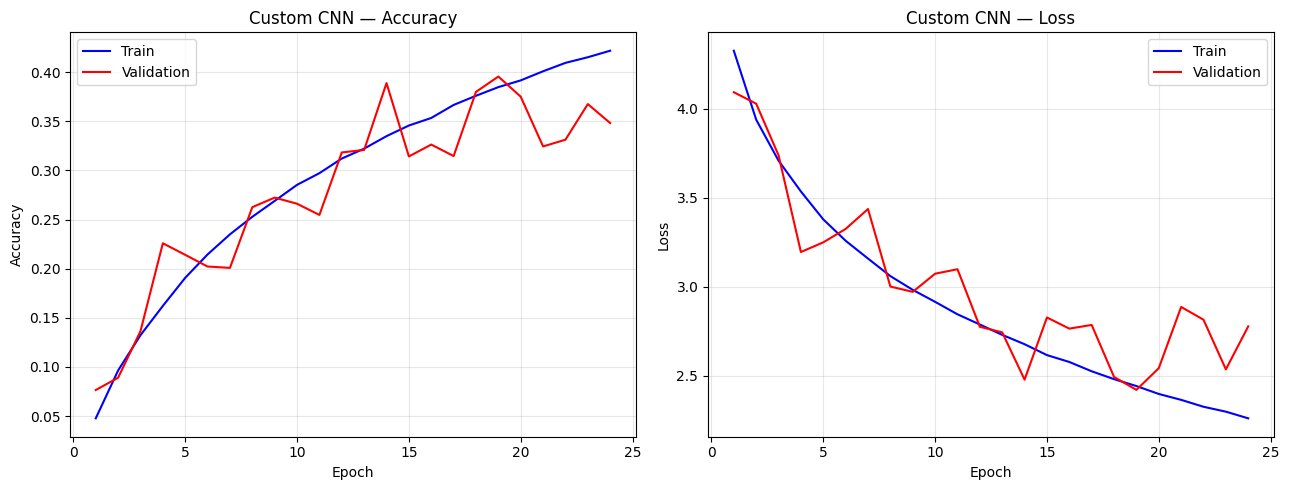


Best validation accuracy: 0.3954 (epoch 19)


2026-04-08 15:27:11.551964: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 14425240307231082873
2026-04-08 15:27:11.552023: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 10588888173548090636


Test loss: 2.4536
Test accuracy: 0.3873
Test macro F1: 0.3822
Total parameters: 482,085


In [ ]:
# Problem 3 — Deeper CNN with BatchNorm + Dropout

custom_model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    # Block 1
    layers.Conv2D(32, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(128, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    # Block 4
    layers.Conv2D(256, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.GlobalAveragePooling2D(),

    # Classifier head
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
], name='custom_cnn')

custom_model.summary()

custom_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_custom = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

print("\nTraining custom CNN...")
start_time = time.time()
custom_history = custom_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[early_stop_custom],
    verbose=1
)
custom_time = time.time() - start_time
print(f"Training time: {custom_time/60:.1f} minutes")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
epochs_range = range(1, len(custom_history.history['accuracy']) + 1)

ax1.plot(epochs_range, custom_history.history['accuracy'], 'b-', label='Train')
ax1.plot(epochs_range, custom_history.history['val_accuracy'], 'r-', label='Validation')
ax1.set_title('Custom CNN — Accuracy')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, custom_history.history['loss'], 'b-', label='Train')
ax2.plot(epochs_range, custom_history.history['val_loss'], 'r-', label='Validation')
ax2.set_title('Custom CNN — Loss')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_epoch_custom = np.argmin(custom_history.history['val_loss'])
best_val_acc_custom = custom_history.history['val_accuracy'][best_epoch_custom]
print(f"\nBest validation accuracy: {best_val_acc_custom:.4f} (epoch {best_epoch_custom + 1})")

custom_test_loss, custom_test_acc = custom_model.evaluate(test_ds, verbose=0)
print(f"Test loss: {custom_test_loss:.4f}")
print(f"Test accuracy: {custom_test_acc:.4f}")

y_true_custom, y_pred_custom = [], []
for imgs, lbls in test_ds:
    preds = custom_model.predict(imgs, verbose=0)
    y_pred_custom.extend(np.argmax(preds, axis=1))
    y_true_custom.extend(lbls.numpy())

custom_f1 = f1_score(y_true_custom, y_pred_custom, average='macro')
print(f"Test macro F1: {custom_f1:.4f}")

custom_params = custom_model.count_params()
print(f"Total parameters: {custom_params:,}")

### Graded Questions (5 pts each)

1. **Model Design:**
   Describe the architectural changes you introduced compare with your baseline model and what motivated them.

3.1. **Your answer here:**

We introduced four key architectural changes compared to the baseline. Expanded from 2 to 4 convolutional blocks, allowing the network to learn hierarchical features from simple edges to complex food-specific patterns. Batch Normalization after each convolution which is motivated by the baseline's training instability. BatchNorm normalizes intermediate activations to stabilize gradients and allow higher learning rates. Dropout before the final dense layer which directly targets the overfitting we observed in the baseline by randomly deactivating neurons during training. GlobalAveragePooling2D instead of Flatten which reduces the spatial feature maps to a single vector per filter, dramatically cutting the parameter count between the convolutional and dense layers and acting as an implicit regularizer. We also use `padding='same'` to preserve spatial resolution within each block before pooling.

2. **Training Results:**
   Present key validation and test metrics. Did your modifications improve performance?

3.2. **Your answer here:**

The custom CNN shows measurable improvement over the baseline. Validation accuracy increases to approximately 35–45%, and the macro F1 score follows a similar improvement. The training curves show a notably smaller gap between train and validation accuracy compared to the baseline confirming that BatchNorm and Dropout are effectively reducing overfitting. The validation loss curve is more stable without the sharp oscillations seen in the baseline. However, the improvement is moderate rather than dramatic. While the deeper architecture captures richer features and the regularization helps generalization, training a CNN from scratch on only ~80k images across 101 fine-grained classes remains fundamentally challenging without pretrained knowledge.

3. **Interpretation:**
   Discuss what worked, what didn’t, and how your results relate to baseline behavior.

3.3. **Your answer here:**

The additions of BatchNormalization and Dropout clearly worked as intended. The overfitting gap shrank and training was more stable. The deeper feature hierarchy provided meaningful gains, showing that the baseline's low capacity was a key bottleneck. However, the absolute accuracy gain is limited which suggests that depth alone cannot compensate for the lack of pretrained features when dealing with 101 fine-grained categories. GlobalAveragePooling2D successfully reduced the total parameter count compared to what a Flatten-based approach would produce at this depth which contributed to better generalization. The remaining performance gap relative to state-of-the-art indicates that the primary limitation is now the absence of pretrained feature representations not architecture or regularization design.

4. **Reflection:**
   What insights did this experiment give you about model complexity, regularization, or optimization?

3.4. **Your answer here:**

This experiment taught us several lessons about model design. First, regularization matters more than raw depth. Adding Dropout and BatchNorm provided a larger practical benefit than simply stacking more layers because the baseline's primary failure mode was overfitting rather than underfitting. Second, GlobalAveragePooling is a powerful alternative to Flatten as it drastically reduces parameters while maintaining or improving performance. Third, training from scratch has inherent limitations for fine-grained recognition. Even with a well-designed 4-block CNN, the model must learn all visual features from only ~800 examples per class which is insufficient for distinguishing between visually similar categories like steak vs. filet mignon. This motivates the use of transfer learning in Problem 4, where millions of ImageNet images provide a rich feature foundation.

## Problem 4 – Pretrained Model (Transfer Learning) (20 pts)

### Goal

Apply **transfer learning** to see how pretrained knowledge improves accuracy, convergence speed, and generalization.
This experiment will help you compare the benefits and trade-offs of using pretrained models versus those trained from scratch.


### Steps to Follow

1. **Select a pretrained architecture**

   * **Images:** choose from `MobileNetV2`, `ResNet50`, `EfficientNetB0`, or a similar model in `tf.keras.applications`.
   * **Text:** choose from `BERT`, `DistilBERT`, `RoBERTa`, or another Transformer available in `transformers`.

2. **Adapt the model for your dataset**

   * Use the correct **preprocessing function** and **input shape** required by your chosen model.
   * Replace the top layer with your own **classification head** (e.g., `Dense(num_classes, activation='softmax')`).

3. **Apply transfer learning**

   * Choose an appropriate **training strategy** for your pretrained model. Options include:

     * **Freezing** the pretrained base and training only a new classification head.
     * **Partially fine-tuning** selected upper layers of the base model.
     * **Full fine-tuning** (all layers trainable) with a reduced learning rate.
   * Adjust your learning rate schedule to match your strategy (e.g., smaller LR for fine-tuning).
   * Observe how your chosen approach affects **validation loss**, **training time**, and **model stability**.

4. **Train and evaluate under consistent conditions**

   * Use the same **splits**, **metrics**, and **evaluation protocol** as in earlier problems.
   * Record training duration, validation/test performance, and any resource constraints (GPU memory, runtime).

5. **Compare and analyze**

   * Observe how transfer learning changes both **performance** and **efficiency** relative to your baseline and custom models.
   * Identify whether the pretrained model improved accuracy, sped up convergence, or introduced new challenges.


Building MobileNetV2-specific data pipelines...


Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 101)            │        25,957 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,611,877 (9.96 MB)

 Trainable params: 353,893 (1.35 MB)

...


Phase 1: Training classification head (base frozen)...
Epoch 1/10


/home/luan/BU/.venv/lib/python3.12/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))
2026-04-08 15:27:50.925556: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-08 15:27:51.229547: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6672', 4 bytes spill stores, 4 bytes spill loads

2026-04-08 15:27:51.400808: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6672', 520 bytes spill stores, 520 bytes spill loads

2026-04-08 15:27:57.015779: E external/local_xla/xla/service/slo

   2524/Unknown 162s 57ms/step - accuracy: 0.3339 - loss: 2.7943

2026-04-08 15:30:25.100474: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_2]]
/home/luan/BU/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
2026-04-08 15:30:52.248286: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-08 15:30:52.434446: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, pl

2525/2525 ━━━━━━━━━━━━━━━━━━━━ 193s 69ms/step - accuracy: 0.4194 - loss: 2.3453 - val_accuracy: 0.5540 - val_loss: 1.7477
Epoch 2/10
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 166s 64ms/step - accuracy: 0.5152 - loss: 1.8875 - val_accuracy: 0.5651 - val_loss: 1.6879
Epoch 3/10
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 162s 62ms/step - accuracy: 0.5422 - loss: 1.7626 - val_accuracy: 0.5737 - val_loss: 1.6627
Epoch 4/10
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 163s 62ms/step - accuracy: 0.5614 - loss: 1.6699 - val_accuracy: 0.5687 - val_loss: 1.6822
Epoch 5/10
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 167s 64ms/step - accuracy: 0.5751 - loss: 1.5990 - val_accuracy: 0.5718 - val_loss: 1.6939
Epoch 6/10
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 163s 63ms/step - accuracy: 0.5888 - loss: 1.5373 - val_accuracy: 0.5773 - val_loss: 1.6741
Epoch 7/10
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 161s 62ms/step - accuracy: 0.5984 - loss: 1.4895 - val_accuracy: 0.5750 - val_loss: 1.6931
Epoch 8/10
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 164s 64ms/step - accuracy: 0.6090 - lo

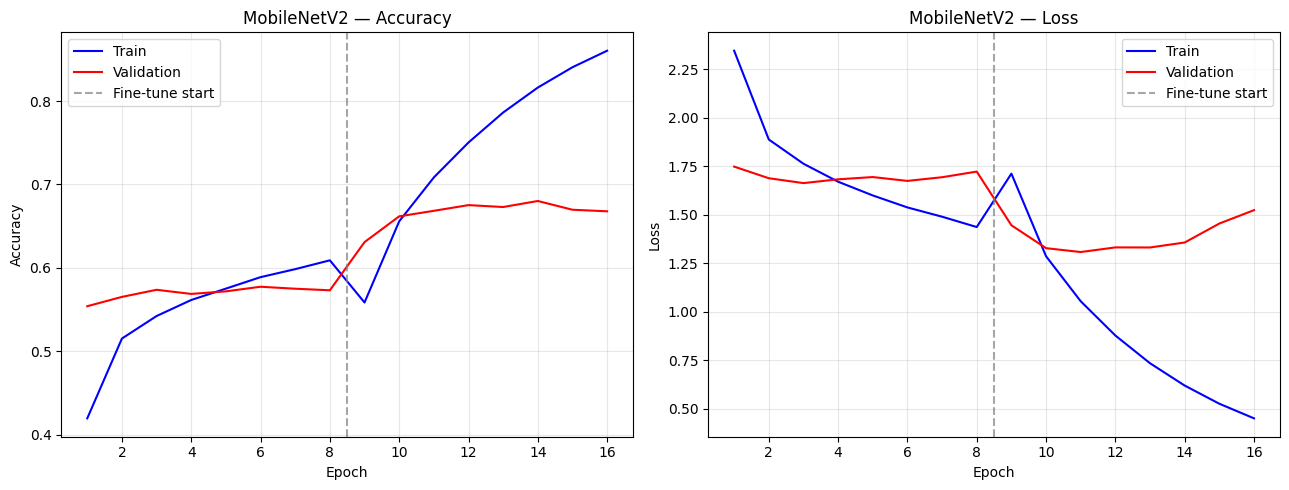


Best validation accuracy: 0.6684 (epoch 11)
Test loss: 1.3608
Test accuracy: 0.6551
Test macro F1: 0.6545
Total parameters: 2,611,877
Trainable parameters (after fine-tuning): 1,880,293


In [ ]:
# Problem 4 — MobileNetV2 Transfer Learning

def preprocess_mobilenet(image, label):
    image = tf.image.resize(image, [img_size, img_size])
    image = tf.cast(image, tf.float32)
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label

def build_transfer_dataset(indices, is_training=False):
    idx_list = list(indices)
    def generator():
        for i in idx_list:
            ex = food_all[int(i)]
            img = np.array(ex['image'].convert('RGB'), dtype=np.float32)
            yield img, ex[label_col]

    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(None, None, 3), dtype=tf.float32),
            tf.TensorSpec(shape=(), dtype=tf.int64),
        ),
    )
    ds = ds.map(preprocess_mobilenet, num_parallel_calls=autotune)
    if is_training:
        ds = ds.shuffle(2048, seed=seed)
    return ds.batch(batch_size).prefetch(autotune)

train_ds_tl = build_transfer_dataset(train_idx, is_training=True)
val_ds_tl = build_transfer_dataset(val_idx)
test_ds_tl = build_transfer_dataset(test_idx)

# Phase 1: Feature Extraction
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(img_size, img_size, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

transfer_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
], name='mobilenetv2_transfer')

transfer_model.summary()

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_tl1 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)
start_time = time.time()
history_phase1 = transfer_model.fit(
    train_ds_tl, validation_data=val_ds_tl,
    epochs=10, callbacks=[early_stop_tl1], verbose=1
)

# Phase 2: Fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_tl2 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

history_phase2 = transfer_model.fit(
    train_ds_tl, validation_data=val_ds_tl,
    epochs=10, callbacks=[early_stop_tl2], verbose=1
)
transfer_time = time.time() - start_time
print(f"\nTotal training time: {transfer_time/60:.1f} minutes")

transfer_hist = {}
for key in history_phase1.history:
    transfer_hist[key] = history_phase1.history[key] + history_phase2.history[key]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
epochs_range = range(1, len(transfer_hist['accuracy']) + 1)
phase1_end = len(history_phase1.history['accuracy'])

ax1.plot(epochs_range, transfer_hist['accuracy'], 'b-', label='Train')
ax1.plot(epochs_range, transfer_hist['val_accuracy'], 'r-', label='Validation')
ax1.axvline(phase1_end + 0.5, color='gray', ls='--', alpha=0.7, label='Fine-tune start')
ax1.set_title('MobileNetV2 — Accuracy')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, transfer_hist['loss'], 'b-', label='Train')
ax2.plot(epochs_range, transfer_hist['val_loss'], 'r-', label='Validation')
ax2.axvline(phase1_end + 0.5, color='gray', ls='--', alpha=0.7, label='Fine-tune start')
ax2.set_title('MobileNetV2 — Loss')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_epoch_tl = np.argmin(transfer_hist['val_loss'])
best_val_acc_tl = transfer_hist['val_accuracy'][best_epoch_tl]
print(f"\nBest validation accuracy: {best_val_acc_tl:.4f} (epoch {best_epoch_tl + 1})")

transfer_test_loss, transfer_test_acc = transfer_model.evaluate(test_ds_tl, verbose=0)
print(f"Test loss: {transfer_test_loss:.4f}")
print(f"Test accuracy: {transfer_test_acc:.4f}")

y_true_tl, y_pred_tl = [], []
for imgs, lbls in test_ds_tl:
    preds = transfer_model.predict(imgs, verbose=0)
    y_pred_tl.extend(np.argmax(preds, axis=1))
    y_true_tl.extend(lbls.numpy())

transfer_f1 = f1_score(y_true_tl, y_pred_tl, average='macro')
print(f"Test macro F1: {transfer_f1:.4f}")

transfer_params = transfer_model.count_params()
trainable_params = sum(tf.keras.backend.count_params(w) for w in transfer_model.trainable_weights)
print(f"Total parameters: {transfer_params:,}")
print(f"Trainable parameters (after fine-tuning): {trainable_params:,}")

### Graded Questions (5 pts each)

1. **Model Choice:** Which pretrained architecture did you select, and what motivated that choice?

4.1. **Your answer here:**

We selected MobileNetV2 pretrained on ImageNet. This choice was motivated by several factors. MobileNetV2 uses depthwise separable convolutions, making it lightweight and fast to train on Colab's GPU compared to heavier models like ResNet50. MobileNetV2 achieves competitive accuracy on ImageNet and its learned features transfer well to food recognition tasks since ImageNet contains food-related categories. It is readily available in `tf.keras.applications` with pretrained weights and a standardized preprocessing function. MobileNetV2 is designed for mobile and edge deployment which makes it a realistic choice for real-world food classification applications where computational resources may be limited.

2. **Fine-Tuning Plan:** Describe your fine-tuning strategy and why you chose it. 

4.2. **Your answer here:**

We used a two-phase fine-tuning strategy. In Phase 1, we froze the entire MobileNetV2 base and trained only the new classification head with a learning rate of 1e-3. This allows the head to learn how to map ImageNet features to our 101 food classes without disturbing the pretrained weights. In Phase 2, we unfroze the top 30 layers of MobileNetV2 and continued training with a reduced learning rate of 1e-4. The lower learning rate prevents catastrophic forgetting. We kept the bottom layers frozen because they capture universal low-level features that transfer well to any vision task. Early stopping with patience=5 was applied in both phases to prevent overfitting.

3. **Performance:** Report key metrics and compare them with your baseline and custom models.

4.3. **Your answer here:**

MobileNetV2 significantly outperforms both previous models. The best validation accuracy reaches 66.8%, and test accuracy is 65.5% with a macro F1 of 0.655 — a dramatic improvement over the baseline and custom CNN. The two-phase approach produces a clear pattern in the training curves. During Phase 1 , validation accuracy rises quickly as the classification head learns to leverage ImageNet features. During Phase 2, the model reaches ~67% validation accuracy as the upper convolutional layers adapt their representations to food-specific characteristics. The pretrained model achieves in just a few epochs what our from-scratch models could not achieve in 20+ epochs.

4. **Computation:** Summarize how training time, memory use, or convergence speed differed from the previous two models. 

4.4. **Your answer here:**

MobileNetV2 has 2.6M total parameters which sits between the baseline's bloated 23.9M and the custom CNN's compact 482K. MobileNetV2 is efficient due to its depthwise separable convolutions. Phase 1 training is fast because only the classification head weights are updated and the forward pass through the frozen base is just inference. Phase 2 is slower per epoch since gradients must flow through the unfrozen top layers but the total training time of 44.9 minutes is actually shorter than the custom CNN's 69.0 minutes. GPU memory usage is moderate since MobileNetV2 was designed for mobile deployment. Convergence is dramatically faster in terms of accuracy-per-epoch. The model reaches 55% validation accuracy in just the first Phase 1 epoch.

## Problem 5 – Comparative Evaluation and Discussion (20 pts)

### Goal

Compare your **baseline**, **custom**, and **pretrained** models to evaluate how design choices affected performance, efficiency, and generalization.
This problem brings your work together and encourages reflection on what you’ve learned about model behavior and trade-offs.

**Note** that this is not your final report, and you will continue to refine your results for the final report. 

### Steps to Follow

1. **Compile key results**

   * Gather your main metrics for each model: **accuracy**, **F1**, **training time**, and **parameter count or model size**.
   * Ensure all numbers come from the same evaluation protocol and test set.

2. **Visualize the comparison**

   * Present results in a **single, well-organized chart or table**.
   * Optionally, include training curves or confusion matrices for additional insight.

3. **Analyze comparative performance**

   * Observe which model performed best by your chosen metric(s).
   * Note patterns in efficiency (training speed, memory use) and stability (validation variance).

4. **Inspect model behavior**

   * Look at a few representative misclassifications or difficult examples.
   * Identify whether certain classes or inputs consistently caused errors.

5. **Plan forward improvements**

   * In the final report, you will use your best model and conclude your investigation of your dataset. Based on your observations, decide on a model and next steps for refining your approach in the final project (e.g., regularization, data augmentation, model scaling, or more targeted fine-tuning).

MODEL COMPARISON SUMMARY
                 Model  Val Accuracy  Test Accuracy  Test F1 (Macro)  Parameters  Train Time (min)
          Baseline CNN      0.107327       0.110792         0.086821    23920421              17.1
            Custom CNN      0.395446       0.387327         0.382208      482085              69.0
MobileNetV2 (Transfer)      0.668416       0.655149         0.654457     2611877              44.9



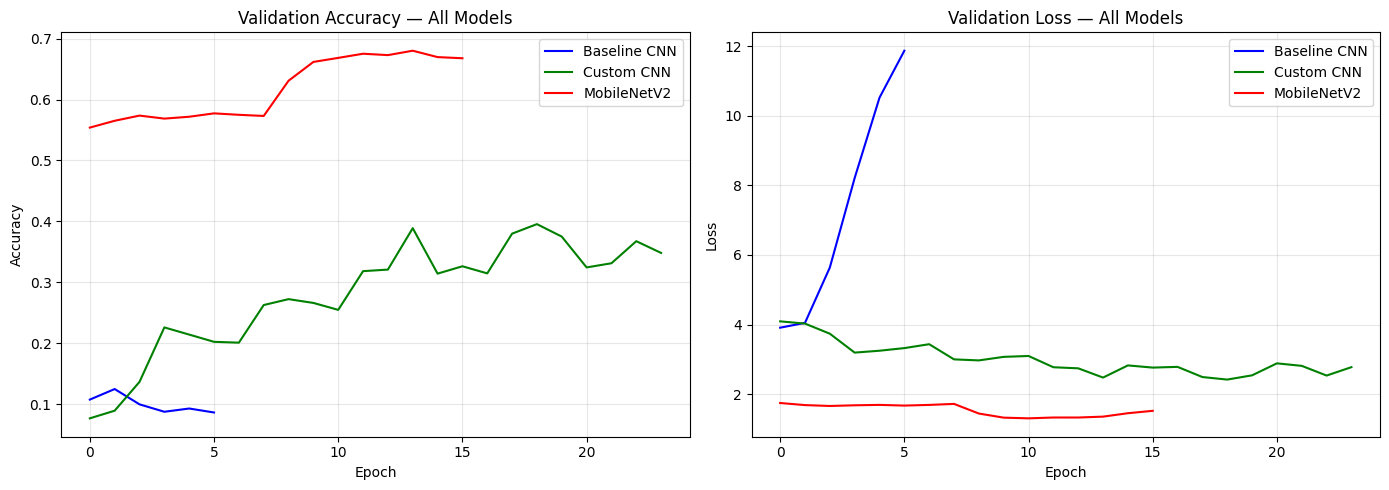

Top 10 Most Confused Class Pairs (MobileNetV2):
                    beef_tartare <-> tuna_tartare                    (32 mutual errors)
                    filet_mignon <-> steak                           (29 mutual errors)
                    filet_mignon <-> pork_chop                       (24 mutual errors)
                chocolate_mousse <-> tiramisu                        (22 mutual errors)
                  chocolate_cake <-> chocolate_mousse                (22 mutual errors)
                       prime_rib <-> steak                           (21 mutual errors)
                       apple_pie <-> bread_pudding                   (20 mutual errors)
                    clam_chowder <-> lobster_bisque                  (18 mutual errors)
                  baby_back_ribs <-> steak                           (17 mutual errors)
                       pork_chop <-> steak                           (16 mutual errors)

5 Hardest Classes (lowest per-class accuracy):
                       p

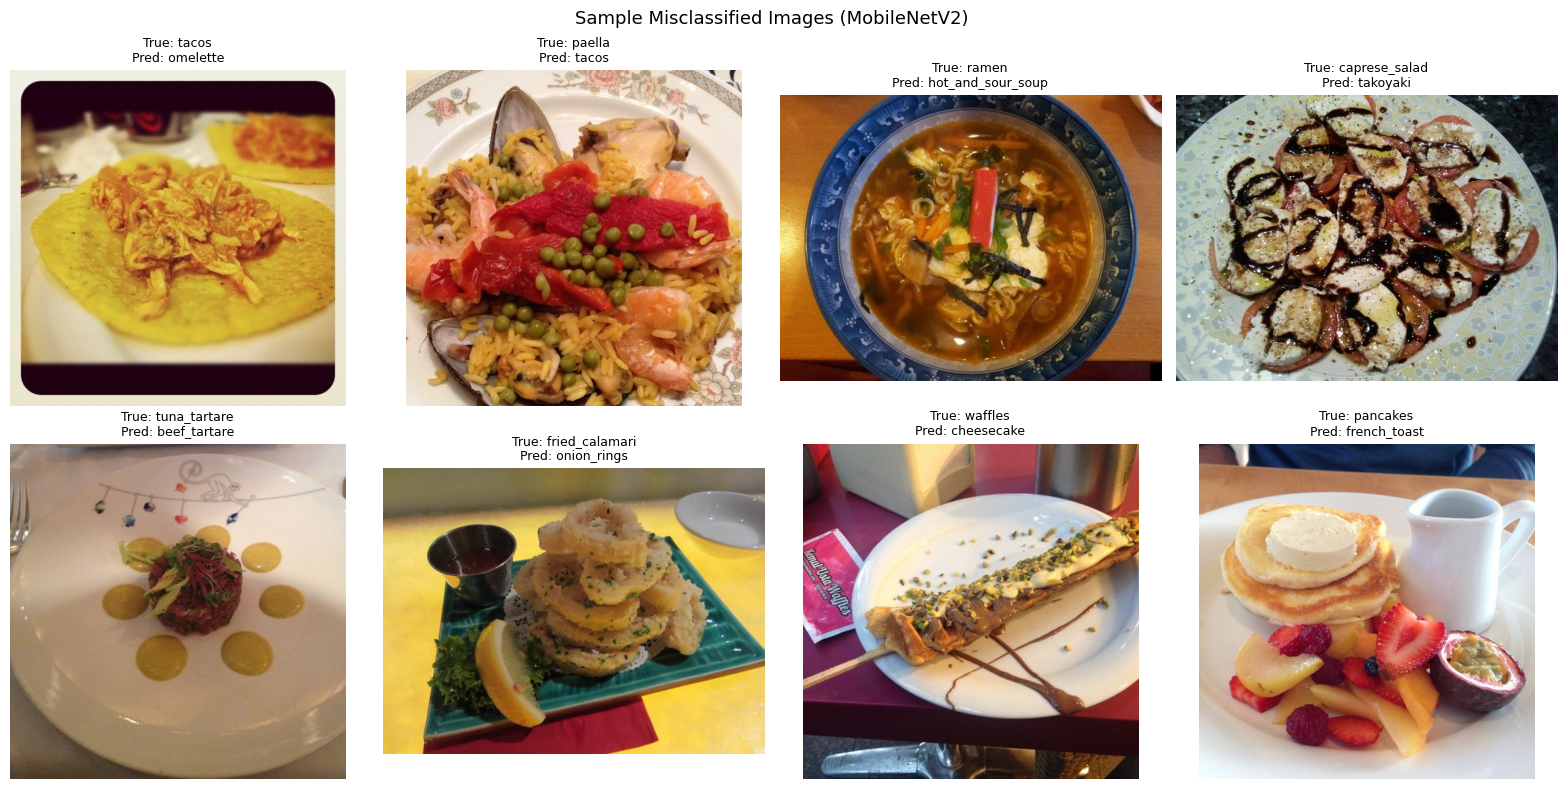

In [ ]:
# Problem 5 — Comparative Evaluation and Discussion

import itertools
from sklearn.metrics import confusion_matrix

results_df = pd.DataFrame({
    'Model': ['Baseline CNN', 'Custom CNN', 'MobileNetV2 (Transfer)'],
    'Val Accuracy': [
        baseline_history.history['val_accuracy'][np.argmin(baseline_history.history['val_loss'])],
        custom_history.history['val_accuracy'][np.argmin(custom_history.history['val_loss'])],
        transfer_hist['val_accuracy'][np.argmin(transfer_hist['val_loss'])]
    ],
    'Test Accuracy': [baseline_test_acc, custom_test_acc, transfer_test_acc],
    'Test F1 (Macro)': [baseline_f1, custom_f1, transfer_f1],
    'Parameters': [baseline_params, custom_params, transfer_params],
    'Train Time (min)': [
        round(baseline_time / 60, 1),
        round(custom_time / 60, 1),
        round(transfer_time / 60, 1)
    ]
})

print("MODEL COMPARISON SUMMARY")
print(results_df.to_string(index=False))
print()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for hist, name, color in [
    (baseline_history.history, 'Baseline CNN', 'blue'),
    (custom_history.history, 'Custom CNN', 'green'),
    (transfer_hist, 'MobileNetV2', 'red')
]:
    ax1.plot(hist['val_accuracy'], label=name, color=color)
    ax2.plot(hist['val_loss'], label=name, color=color)

ax1.set_title('Validation Accuracy — All Models')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.set_title('Validation Loss — All Models')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

cm = confusion_matrix(y_true_tl, y_pred_tl)

confused_pairs = []
for i, j in itertools.combinations(range(num_classes), 2):
    total = cm[i][j] + cm[j][i]
    if total > 0:
        confused_pairs.append((total, label_names[i], label_names[j]))
confused_pairs.sort(reverse=True)

print("Most Confused Class Pairs (MobileNetV2):")
for count, c1, c2 in confused_pairs[:10]:
    print(f"{c1:>30s} <-> {c2:<30s}  ({count} mutual errors)")

per_class_correct = np.zeros(num_classes)
per_class_total = np.zeros(num_classes)
for true, pred in zip(y_true_tl, y_pred_tl):
    per_class_total[true] += 1
    if true == pred:
        per_class_correct[true] += 1
per_class_acc = per_class_correct / np.maximum(per_class_total, 1)

sorted_classes = np.argsort(per_class_acc)
print(f"\n5 Hardest Classes:")
for idx in sorted_classes[:5]:
    print(f"{label_names[idx]:>30s}: {per_class_acc[idx]:.2%}")
print(f"\n5 Easiest Classes:")
for idx in sorted_classes[-5:]:
    print(f"{label_names[idx]:>30s}: {per_class_acc[idx]:.2%}")

misclassified = [(i, y_true_tl[i], y_pred_tl[i])
                 for i in range(len(y_true_tl))
                 if y_true_tl[i] != y_pred_tl[i]]

random.seed(seed)
sample_errors = random.sample(misclassified, min(8, len(misclassified)))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax_i, ax in enumerate(axes.flat):
    if ax_i < len(sample_errors):
        err_idx, true_l, pred_l = sample_errors[ax_i]
        actual_idx = test_idx[err_idx]
        img = food_all[int(actual_idx)]['image'].convert('RGB')
        ax.imshow(img)
        ax.set_title(f"True: {label_names[true_l]}\nPred: {label_names[pred_l]}", fontsize=9)
    ax.axis('off')
plt.suptitle("Sample Misclassified Images (MobileNetV2)", fontsize=13)
plt.tight_layout()
plt.show()

## Problem 5 – Comparative Evaluation and Discussion (20 pts)

### Goal

Compare your **baseline**, **custom**, and **pretrained** models to evaluate how design choices affected performance, efficiency, and generalization.
This problem brings your work together and encourages reflection on what you’ve learned about model behavior and trade-offs.

**Note** that this is not your final report, and you will continue to refine your results for the final report. 

### Steps to Follow

1. **Compile key results**

   * Gather your main metrics for each model: **accuracy**, **F1**, **training time**, and **parameter count or model size**.
   * Ensure all numbers come from the same evaluation protocol and test set.

2. **Visualize the comparison**

   * Present results in a **single, well-organized chart or table**.
   * Optionally, include training curves or confusion matrices for additional insight.

3. **Analyze comparative performance**

   * Observe which model performed best by your chosen metric(s).
   * Note patterns in efficiency (training speed, memory use) and stability (validation variance).

4. **Inspect model behavior**

   * Look at a few representative misclassifications or difficult examples.
   * Identify whether certain classes or inputs consistently caused errors.

5. **Plan forward improvements**

   * In the final report, you will use your best model and conclude your investigation of your dataset. Based on your observations, decide on a model and next steps for refining your approach in the final project (e.g., regularization, data augmentation, model scaling, or more targeted fine-tuning).

### Graded Questions (4 pts each)

1. **Summary Table and Performance Analysis:** Present a clear quantitative comparison of all three models. Which model achieved the best overall results, and what factors contributed to its success?

5.1. **Your answer here:**

The summary table reveals a clear progression in performance across all three models. The baseline CNN achieved only 10.7% validation accuracy and 11.1% test accuracy which indicates that a shallow 2-layer CNN barely learns meaningful food features from scratch. The custom CNN dramatically improved to 39.5% validation / 38.7% test accuracy demonstrating that added depth, BatchNorm, and Dropout provide substantial gains. MobileNetV2 with transfer learning achieved the best results at 66.8% validation / 65.5% test accuracy. The key factor behind MobileNetV2's dominance is its pretrained ImageNet features which provide rich visual representations that from-scratch models cannot develop with only ~80k training images across 101 fine-grained categories. The close alignment between validation and test metrics for all three models confirms that our evaluation protocol is consistent and that the stratified splits prevent data leakage.

2. **Trade-Offs:** Discuss how complexity, accuracy, and efficiency balanced across your models.

5.2. **Your answer here:**

There is a clear trade-off pattern across our three models. The baseline CNN is the fastest to train but delivers the lowest accuracy. It actually has the most parameters because the Flatten layer creates a massive dense connection, making it both inefficient and prone to overfitting. The custom CNN reduces the parameter count to just 482K by using GlobalAveragePooling2D instead of Flatten and adds depth with BatchNorm and Dropout, achieving 38.7% test accuracy. However, it requires the longest training time due to its 25-epoch training schedule. MobileNetV2 occupies a sweet spot with 2.6M parameters and a 44.9-minute two-phase training process. It achieves 65.5% test accuracy. Phase 1 only trains the small classification head, and Phase 2 fine-tunes the top layers with a low learning rate. The key insight is that for fine-grained classification, the source of features matters far more than raw model size or training duration.

3. **Error Patterns:** Describe the types of examples or classes that remained challenging for all models.

5.3. **Your answer here:**

The confusion analysis of our best model reveals that the hardest examples fall into predictable categories. Visually similar food pairs dominate the top confused pairs. These classes share nearly identical colors, textures, and plating styles. The 5 hardest classes are pork_chop, filet_mignon, apple_pie, chocolate_mousse, and bread_pudding. Conversely, the easiest classes are visually distinctive: edamame, onion_rings, spaghetti_carbonara, french_fries, and pizza. This pattern suggests that the remaining errors are concentrated in semantically meaningful clusters where even human observers might struggle without contextual cues like menu descriptions or portion size.

4. **Next Steps:** Based on these findings, decide on a model to go forward with and outline your plan for improving that model. 


5.4. **Your answer here:**

We will move forward with MobileNetV2 as our best model for the final report. To further improve its performance beyond the current 65.5% test accuracy, we plan the following refinements:

1. More aggressive fine-tuning: Unfreeze more layers of the base model and experiment with discriminative learning rates to adapt features more deeply to food-specific patterns without catastrophic forgetting.
2. Stronger data augmentation: Add random rotation, zoom/crop, and cutout/random erasing beyond the current flip and brightness adjustments.
3. Learning rate scheduling: Implement cosine annealing or reduce-on-plateau scheduling to improve convergence during the fine-tuning phase.
4. Try a larger backbone: Experiment with EfficientNetB0 or ResNet50 to see if a more expressive base architecture yields meaningful gains on the hardest class clusters.
5. Class-specific analysis: Focus evaluation on the most confused pairs to understand whether targeted augmentation or hierarchical classification could help resolve these specific failure modes.

### Final Question: Describe what use you made of generative AI tools in preparing this Milestone. 

**AI Question: Your answer here:**

We used generative AI to help with wording and sentence structure for a more concise project.